In [17]:
# importing importi=ant libraries
import pandas as pd
import numpy as np 
from matplotlib import pyplot as plt 
import seaborn as sns
import re

In [3]:
# loading Dataset in notebook
df = pd.read_csv("clash_data.csv")

In [4]:
df

,Card,Card Level (Spawn Level),Cost,Count,Crown Tower Damage,Damage,Damage per second,Death Damage,Health (+Shield),Hit Speed,...,Maximum Spawned,Radius,Range,Spawn DPS,Spawn Damage,Spawn Health,Spawn Speed,Spawner Health,Troop Spawned,Type
0,Archers,NaN,3.0,2,NaN,86,71,0.0,254,1.2,...,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,Troops and Defenses
1,Baby Dragon,NaN,4.0,1,NaN,133,83,0.0,"1,064",1.6,...,NaN,NaN,3.5,NaN,NaN,NaN,NaN,NaN,NaN,Troops and Defenses
2,Balloon,NaN,5.0,1,NaN,798,266,272.0,"1,396",3,...,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,Troops and Defenses
3,Bandit,NaN,3.0,1,NaN,160,160,0.0,780,1,...,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,Troops and Defenses
4,Barbarians,NaN,5.0,4,NaN,159,106,0.0,636,1.5,...,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,Troops and Defenses
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,Lightning,NaN,6.0,NaN,346.0,864,NaN,NaN,NaN,NaN,...,NaN,3.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Damaging Spells
66,Poison,NaN,4.0,NaN,240.0,600,NaN,NaN,NaN,NaN,...,NaN,3.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Damaging Spells
67,Rocket,NaN,6.0,NaN,493.0,"1,232",NaN,NaN,NaN,NaN,...,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Damaging Spells
68,The Log,NaN,2.0,NaN,96.0,240,NaN,NaN,NaN,NaN,...,NaN,3.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Damaging Spells


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Card                      70 non-null     object 
 1   Card Level (Spawn Level)  6 non-null      object 
 2   Cost                      68 non-null     float64
 3   Count                     57 non-null     object 
 4   Crown Tower Damage        7 non-null      float64
 5   Damage                    64 non-null     object 
 6   Damage per second         57 non-null     object 
 7   Death Damage              57 non-null     float64
 8   Health (+Shield)          57 non-null     object 
 9   Hit Speed                 57 non-null     object 
 10  Level                     64 non-null     float64
 11  Maximum Spawned           6 non-null      float64
 12  Radius                    7 non-null      float64
 13  Range                     57 non-null     object 
 14  Spawn DPS   

In [5]:
df.isnull().sum()

Card                         0
Card Level (Spawn Level)    64
Cost                         2
Count                       13
Crown Tower Damage          63
Damage                       6
Damage per second           13
Death Damage                13
Health (+Shield)            13
Hit Speed                   13
Level                        6
Maximum Spawned             64
Radius                      63
Range                       13
Spawn DPS                   64
Spawn Damage                64
Spawn Health                64
Spawn Speed                 64
Spawner Health              64
Troop Spawned               64
Type                         0
dtype: int64

In [6]:
# values missing percentage 
(df.isnull().sum() / len(df)) * 100

Card                         0.000000
Card Level (Spawn Level)    91.428571
Cost                         2.857143
Count                       18.571429
Crown Tower Damage          90.000000
Damage                       8.571429
Damage per second           18.571429
Death Damage                18.571429
Health (+Shield)            18.571429
Hit Speed                   18.571429
Level                        8.571429
Maximum Spawned             91.428571
Radius                      90.000000
Range                       18.571429
Spawn DPS                   91.428571
Spawn Damage                91.428571
Spawn Health                91.428571
Spawn Speed                 91.428571
Spawner Health              91.428571
Troop Spawned               91.428571
Type                         0.000000
dtype: float64

In [8]:
df.rename(columns={
    "Card":"card",
    "Cost":"cost",
    "Count":"count",
    "Damage":"damage",
    "Death Damage":"Death_damage",
    "Health (+Shield)":"sheild",
    "Card Level (Spawn Level)": "card_level",
    "Crown Tower Damage": "tower_damage",
    "Damage per second": "dps",
    "Hit Speed":"hit_speed",
    "Level":"level",
    "Maximum Spawned":"max_spawn",
    "Radius":"radius",
    "Range":"range",
    "Spawn Damage":"spawn_damage",
    "Spawn DPS":"spawn_dps",
    "Spawn Health":"spawn_health",
    "Spawn Speed":"spawn_speed",
    "Spawner Health":"spawner_health",
    "Spawn Damage":"spawn_damage",
    "Troop Spawned":"troop_spawned",
    "Type":"type"
}, inplace=True)

In [9]:
df

,card,card_level,cost,count,tower_damage,damage,dps,Death_damage,sheild,hit_speed,...,max_spawn,radius,range,spawn_dps,spawn_damage,spawn_health,spawn_speed,spawner_health,troop_spawned,type
0,Archers,NaN,3.0,2,NaN,86,71,0.0,254,1.2,...,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,Troops and Defenses
1,Baby Dragon,NaN,4.0,1,NaN,133,83,0.0,"1,064",1.6,...,NaN,NaN,3.5,NaN,NaN,NaN,NaN,NaN,NaN,Troops and Defenses
2,Balloon,NaN,5.0,1,NaN,798,266,272.0,"1,396",3,...,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,Troops and Defenses
3,Bandit,NaN,3.0,1,NaN,160,160,0.0,780,1,...,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,Troops and Defenses
4,Barbarians,NaN,5.0,4,NaN,159,106,0.0,636,1.5,...,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,Troops and Defenses
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,Lightning,NaN,6.0,NaN,346.0,864,NaN,NaN,NaN,NaN,...,NaN,3.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Damaging Spells
66,Poison,NaN,4.0,NaN,240.0,600,NaN,NaN,NaN,NaN,...,NaN,3.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Damaging Spells
67,Rocket,NaN,6.0,NaN,493.0,"1,232",NaN,NaN,NaN,NaN,...,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Damaging Spells
68,The Log,NaN,2.0,NaN,96.0,240,NaN,NaN,NaN,NaN,...,NaN,3.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Damaging Spells


In [10]:
df.reset_index(drop=True, inplace=True)
df.index = df.index + 1

In [11]:
df["card"].unique()

array(['Archers', 'Baby Dragon', 'Balloon', 'Bandit', 'Barbarians',
       'Bats', 'Battle Ram', 'Bomb Tower', 'Bomber', 'Bowler', 'Cannon',
       'Cannon Cart', 'Dark Prince', 'Dart Goblin', 'Electro Wizard',
       'Elite Barbarians', 'Executioner', 'Fire Spirits', 'Giant',
       'Giant Skeleton', 'Goblin Gang', 'Goblins', 'Golem', 'Golemite',
       'Guards', 'Hog Rider', 'Ice Golem', 'Ice Spirit', 'Ice Wizard',
       'Inferno Dragon', 'Inferno Tower', 'Knight', 'Lava Hound',
       'Lava Pup', 'Lumberjack', 'Mega Minion', 'Mini P.E.K.K.A.',
       'Miner', 'Minions', 'Minion Horde', 'Mortar', 'Musketeer',
       'Night Witch', 'P.E.K.K.A.', 'Prince', 'Princess', 'Royal Giant',
       'Skeletons', 'Skeleton Army', 'Sparky', 'Spear Goblins', 'Tesla',
       'Three Musketeers', 'Valkyrie', 'Witch', 'Wizard', 'X-Bow',
       'Barbarian Hut', 'Furnace', 'Goblin Barrel', 'Goblin Hut',
       'Graveyard', 'Tombstone', 'Arrows', 'Fireball', 'Lightning',
       'Poison', 'Rocket', 'The L

In [12]:
df["card_level"].unique()

array([nan, '7 (9)', '4 (9)', '1 (9)'], dtype=object)

In [13]:
df[['card_level_d', 'spawn_level']] = df['card_level'].str.extract(
    r'(\d+)\s*\((\d+)\)'
)

In [14]:
df

,card,card_level,cost,count,tower_damage,damage,dps,Death_damage,sheild,hit_speed,...,range,spawn_dps,spawn_damage,spawn_health,spawn_speed,spawner_health,troop_spawned,type,card_level_d,spawn_level
1,Archers,NaN,3.0,2,NaN,86,71,0.0,254,1.2,...,5,NaN,NaN,NaN,NaN,NaN,NaN,Troops and Defenses,NaN,NaN
2,Baby Dragon,NaN,4.0,1,NaN,133,83,0.0,"1,064",1.6,...,3.5,NaN,NaN,NaN,NaN,NaN,NaN,Troops and Defenses,NaN,NaN
3,Balloon,NaN,5.0,1,NaN,798,266,272.0,"1,396",3,...,0,NaN,NaN,NaN,NaN,NaN,NaN,Troops and Defenses,NaN,NaN
4,Bandit,NaN,3.0,1,NaN,160,160,0.0,780,1,...,0,NaN,NaN,NaN,NaN,NaN,NaN,Troops and Defenses,NaN,NaN
5,Barbarians,NaN,5.0,4,NaN,159,106,0.0,636,1.5,...,0,NaN,NaN,NaN,NaN,NaN,NaN,Troops and Defenses,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,Lightning,NaN,6.0,NaN,346.0,864,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Damaging Spells,NaN,NaN
67,Poison,NaN,4.0,NaN,240.0,600,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Damaging Spells,NaN,NaN
68,Rocket,NaN,6.0,NaN,493.0,"1,232",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Damaging Spells,NaN,NaN
69,The Log,NaN,2.0,NaN,96.0,240,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Damaging Spells,NaN,NaN


In [18]:
df.rename(columns = {"card_level_d":"card_level"},inplace = True)
df

,card,cost,count,tower_damage,damage,dps,Death_damage,sheild,hit_speed,level,...,range,spawn_dps,spawn_damage,spawn_health,spawn_speed,Spawner Health,troop_spawned,type,card_level,spawn_level
1,Archers,3.0,2,NaN,86,71,0.0,254,1.2,9.0,...,5,NaN,NaN,NaN,NaN,NaN,NaN,Troops and Defenses,NaN,NaN
2,Baby Dragon,4.0,1,NaN,133,83,0.0,"1,064",1.6,4.0,...,3.5,NaN,NaN,NaN,NaN,NaN,NaN,Troops and Defenses,NaN,NaN
3,Balloon,5.0,1,NaN,798,266,272.0,"1,396",3,4.0,...,0,NaN,NaN,NaN,NaN,NaN,NaN,Troops and Defenses,NaN,NaN
4,Bandit,3.0,1,NaN,160,160,0.0,780,1,1.0,...,0,NaN,NaN,NaN,NaN,NaN,NaN,Troops and Defenses,NaN,NaN
5,Barbarians,5.0,4,NaN,159,106,0.0,636,1.5,9.0,...,0,NaN,NaN,NaN,NaN,NaN,NaN,Troops and Defenses,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,Lightning,6.0,NaN,346.0,864,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Damaging Spells,NaN,NaN
67,Poison,4.0,NaN,240.0,600,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Damaging Spells,NaN,NaN
68,Rocket,6.0,NaN,493.0,"1,232",NaN,NaN,NaN,NaN,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Damaging Spells,NaN,NaN
69,The Log,2.0,NaN,96.0,240,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Damaging Spells,NaN,NaN


In [18]:
df["damage"].unique()

array(['86', '133', '798', '160', '159', '67', '246', '176', '271', '239',
       '127', '203', '206', '93', '200', '254', '280', '169', '211',
       '172', '106/50', '106', '259', '53', '264', '70', '95', '69',
       '30-350', '35-704', '45', '258', '598', '84', '228', '260', '678',
       '325', '140', '1,300', '50', '135', '26', nan, '243', '572', '864',
       '600', '1,232', '240'], dtype=object)

In [19]:
import re

In [20]:
def clean_damage(val):
    if pd.isnull(val):
        return np.nan
    
    val = str(val).replace(',', '').strip()
    
    # Case 1: Range (e.g., 30-350)
    if '-' in val:
        parts = re.split(r'-', val)
        if len(parts) == 2:
            return (float(parts[0]) + float(parts[1])) / 2
    
    # Case 2: Fraction (e.g., 106/50)
    if '/' in val:
        parts = re.split(r'/', val)
        if len(parts) == 2:
            return float(parts[0]) / float(parts[1])
    
    # Case 3: Normal number
    try:
        return float(val)
    except:
        return np.nan

In [21]:
df['damage'] = df['damage'].apply(clean_damage)

In [22]:
df["damage"].unique()

array([  86.  ,  133.  ,  798.  ,  160.  ,  159.  ,   67.  ,  246.  ,
        176.  ,  271.  ,  239.  ,  127.  ,  203.  ,  206.  ,   93.  ,
        200.  ,  254.  ,  280.  ,  169.  ,  211.  ,  172.  ,    2.12,
        106.  ,  259.  ,   53.  ,  264.  ,   70.  ,   95.  ,   69.  ,
        190.  ,  369.5 ,   45.  ,  258.  ,  598.  ,   84.  ,  228.  ,
        260.  ,  678.  ,  325.  ,  140.  , 1300.  ,   50.  ,  135.  ,
         26.  ,     nan,  243.  ,  572.  ,  864.  ,  600.  , 1232.  ,
        240.  ])

In [23]:
df['dps'] = df['dps'].apply(clean_damage)

In [24]:
df["dps"].unique()

array([ 71.        ,  83.        , 266.        , 160.        ,
       106.        ,  67.        ,   0.        , 110.        ,
       142.        ,  95.        , 158.        , 169.        ,
       147.        , 132.        , 111.        , 116.        ,
       140.        , 114.        ,   2.52631579,  96.        ,
       103.        ,  21.        , 176.        ,  28.        ,
        40.        , 475.        , 923.5       , 144.        ,
        34.        ,  45.        , 285.        , 172.        ,
       332.        , 133.        ,  84.        , 173.        ,
       376.        , 216.        ,  46.        ,  93.        ,
       260.        ,  38.        , 168.        ,  98.        ,
       163.        , 104.        ,          nan])

In [25]:
# cahnged datatype of all the columns accodeing to requirement.  
numeric_cols = ['damage', 'count','hit_speed','range','card_level','spawn_level','spawn_health']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [26]:
df["sheild"].unique()

array(['254', '1,064', '1,396', '780', '636', '67', '756', '1,672', '311',
       '1,596', '742', '696 (+696)', '977 (+266)', '216', '590', '970',
       '1,010', '91', '3,344', '2,660', '169/110', '169', '4,256', '864',
       '86 (+199)', '1,408', '1,047', '190', '665', '1,070', '1,399',
       '3,000', '179', '990', '695', '1,056', '1,000', '1,272', '598',
       '750', '3,458', '1,463', '2,544', '1,200', '110', '954', '1,548',
       '696', '1,330', nan], dtype=object)

In [27]:
def split_hp(val):
    if pd.isnull(val):
        return pd.Series([np.nan, np.nan])
    
    val = str(val).replace(',', '').strip()
    
    # Case 1: Shield format (e.g., 696 (+696))
    match = re.match(r'(\d+)\s*\(\+(\d+)\)', val)
    if match:
        base = float(match.group(1))
        shield = float(match.group(2))
        return pd.Series([base, shield])
    
    # Case 2: Fraction-like (e.g., 169/110) → treat as base/shield
    if '/' in val:
        parts = val.split('/')
        if len(parts) == 2:
            return pd.Series([float(parts[0]), float(parts[1])])
    
    # Case 3: Normal value → only base HP
    try:
        return pd.Series([float(val), 0])  # no shield
    except:
        return pd.Series([np.nan, np.nan])

In [28]:
df[['base_hp', 'shield_hp']] = df['sheild'].apply(split_hp)

In [29]:
df

,card,card_level,cost,count,tower_damage,damage,dps,Death_damage,sheild,hit_speed,...,spawn_damage,spawn_health,spawn_speed,spawner_health,troop_spawned,type,card_level_d,spawn_level,base_hp,shield_hp
1,Archers,NaN,3.0,2.0,NaN,86.0,71.0,0.0,254,1.2,...,NaN,NaN,NaN,NaN,NaN,Troops and Defenses,NaN,NaN,254.0,0.0
2,Baby Dragon,NaN,4.0,1.0,NaN,133.0,83.0,0.0,"1,064",1.6,...,NaN,NaN,NaN,NaN,NaN,Troops and Defenses,NaN,NaN,1064.0,0.0
3,Balloon,NaN,5.0,1.0,NaN,798.0,266.0,272.0,"1,396",3.0,...,NaN,NaN,NaN,NaN,NaN,Troops and Defenses,NaN,NaN,1396.0,0.0
4,Bandit,NaN,3.0,1.0,NaN,160.0,160.0,0.0,780,1.0,...,NaN,NaN,NaN,NaN,NaN,Troops and Defenses,NaN,NaN,780.0,0.0
5,Barbarians,NaN,5.0,4.0,NaN,159.0,106.0,0.0,636,1.5,...,NaN,NaN,NaN,NaN,NaN,Troops and Defenses,NaN,NaN,636.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,Lightning,NaN,6.0,NaN,346.0,864.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Damaging Spells,NaN,NaN,NaN,NaN
67,Poison,NaN,4.0,NaN,240.0,600.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Damaging Spells,NaN,NaN,NaN,NaN
68,Rocket,NaN,6.0,NaN,493.0,1232.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Damaging Spells,NaN,NaN,NaN,NaN
69,The Log,NaN,2.0,NaN,96.0,240.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Damaging Spells,NaN,NaN,NaN,NaN


In [30]:
df.drop('sheild', axis=1, inplace=True)

In [48]:
df.dtypes

card                  object
cost                 float64
count                float64
tower_damage         float64
damage               float64
dps                  float64
Death_damage         float64
hit_speed            float64
level                float64
max_spawn            float64
radius               float64
range                float64
spawn_dps            float64
spawn_damage         float64
spawn_health         float64
spawn_speed          float64
spawner_health        object
troop_spawned       category
type                category
card_level_d          object
spawn_level          float64
base_hp              float64
shield_hp            float64
has_spawn              int64
has_tower_damage       int64
dtype: object

In [45]:
df = df.drop('card_level', axis=1)

In [52]:
df.rename(columns = {"card_level_d":"card_level"}, inplace = True)

In [53]:
df

,card,cost,count,tower_damage,damage,dps,Death_damage,hit_speed,level,max_spawn,...,spawn_speed,spawner_health,troop_spawned,type,card_level,spawn_level,base_hp,shield_hp,has_spawn,has_tower_damage
1,Archers,3.0,2.0,0.0,86.0,71.0,0.0,1.20,9.0,0.0,...,0.0,0,None,Troops and Defenses,NaN,0.0,254.0,0.0,0,0
2,Baby Dragon,4.0,1.0,0.0,133.0,83.0,0.0,1.60,4.0,0.0,...,0.0,0,None,Troops and Defenses,NaN,0.0,1064.0,0.0,0,0
3,Balloon,5.0,1.0,0.0,798.0,266.0,272.0,3.00,4.0,0.0,...,0.0,0,None,Troops and Defenses,NaN,0.0,1396.0,0.0,0,0
4,Bandit,3.0,1.0,0.0,160.0,160.0,0.0,1.00,1.0,0.0,...,0.0,0,None,Troops and Defenses,NaN,0.0,780.0,0.0,0,0
5,Barbarians,5.0,4.0,0.0,159.0,106.0,0.0,1.50,9.0,0.0,...,0.0,0,None,Troops and Defenses,NaN,0.0,636.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,Lightning,6.0,1.0,346.0,864.0,111.0,0.0,1.35,4.0,0.0,...,0.0,0,None,Damaging Spells,NaN,0.0,780.0,0.0,0,1
67,Poison,4.0,1.0,240.0,600.0,111.0,0.0,1.35,4.0,0.0,...,0.0,0,None,Damaging Spells,NaN,0.0,780.0,0.0,0,1
68,Rocket,6.0,1.0,493.0,1232.0,111.0,0.0,1.35,7.0,0.0,...,0.0,0,None,Damaging Spells,NaN,0.0,780.0,0.0,0,1
69,The Log,2.0,1.0,96.0,240.0,111.0,0.0,1.35,1.0,0.0,...,0.0,0,None,Damaging Spells,NaN,0.0,780.0,0.0,0,1


## Handling Null Values 

In [47]:
df.isnull().sum()

card                 0
cost                 0
count                0
tower_damage         0
damage               0
dps                  0
Death_damage         0
hit_speed            0
level                0
max_spawn            0
radius               0
range                0
spawn_dps            0
spawn_damage         0
spawn_health         0
spawn_speed          0
spawner_health       0
troop_spawned        0
type                 0
card_level_d        64
spawn_level          0
base_hp              0
shield_hp            0
has_spawn            0
has_tower_damage     0
dtype: int64

In [54]:
# replaced null values with none as all cards does not spawn units 
df['troop_spawned'] = df['troop_spawned'].fillna('None')

In [55]:
# as these columns are core properties that each card should posses that means values are missing so we will fill them with median 
core_cols = ['cost', 'damage', 'dps', 'hit_speed', 'range', 'base_hp']

for col in core_cols:
    df[col] = df[col].fillna(df[col].median())

In [56]:
# as their are some special carda that can deal damage to towers and some that can spawn units so we add indicator coluns representing such feature
df['has_spawn'] = df['spawn_damage'].notnull().astype(int)
df['has_tower_damage'] = df['tower_damage'].notnull().astype(int)

In [57]:
# as these remaining cards thses properties are not available so we fill them with 0 
conditional_cols = [
    'tower_damage', 'max_spawn', 'radius',
    'spawn_dps', 'spawn_damage', 'spawn_health',
    'spawn_speed', 'spawner_health',
    'card_level', 'spawn_level'
]

for col in conditional_cols:
    df[col] = df[col].fillna(0)

In [58]:
# some caards only deploy 1 unit at once 
df['count'] = df['count'].fillna(1)

In [59]:
# all cards do not deal death damage so we fill them with zero 
df['Death_damage'] = df['Death_damage'].fillna(0)

In [60]:
# all cards do not posses shields
df['shield_hp'] = df['shield_hp'].fillna(0)

In [61]:
df['level'] = df['level'].fillna(df['level'].median())

In [62]:
df['troop_spawned'] = df['troop_spawned'].astype('category')

In [63]:
df['type'] = df['type'].astype('category')

In [64]:
df.isnull().sum()

card                0
cost                0
count               0
tower_damage        0
damage              0
dps                 0
Death_damage        0
hit_speed           0
level               0
max_spawn           0
radius              0
range               0
spawn_dps           0
spawn_damage        0
spawn_health        0
spawn_speed         0
spawner_health      0
troop_spawned       0
type                0
card_level          0
spawn_level         0
base_hp             0
shield_hp           0
has_spawn           0
has_tower_damage    0
dtype: int64

## checking statistical analytics

In [65]:
df.describe()

,cost,count,tower_damage,damage,dps,Death_damage,hit_speed,level,max_spawn,radius,range,spawn_dps,spawn_damage,spawn_health,spawn_speed,spawn_level,base_hp,shield_hp,has_spawn,has_tower_damage
count,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.0,70.0
mean,4.128571,1.671429,22.371429,238.680286,134.600376,23.014286,1.445000,5.814286,1.014286,0.312857,2.521429,5.342857,8.828571,16.285714,0.461429,0.771429,963.828571,18.157143,1.0,1.0
std,1.578124,1.878339,81.710725,244.384741,126.573823,122.032722,0.859017,2.865552,3.609540,0.973254,2.562884,20.457014,32.100373,80.203571,2.132447,2.537667,823.622398,91.982613,0.0,0.0
min,1.000000,1.000000,0.000000,2.120000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000,0.000000,1.0,1.0
25%,3.000000,1.000000,0.000000,97.750000,83.250000,0.000000,1.025000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,598.000000,0.000000,1.0,1.0
50%,4.000000,1.000000,0.000000,176.000000,111.000000,0.000000,1.350000,7.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,780.000000,0.000000,1.0,1.0
75%,5.000000,1.000000,0.000000,245.250000,159.500000,0.000000,1.500000,9.000000,0.000000,0.000000,4.875000,0.000000,0.000000,0.000000,0.000000,0.000000,1068.500000,0.000000,1.0,1.0
max,9.000000,14.000000,493.000000,1300.000000,923.500000,957.000000,5.000000,9.000000,18.000000,4.000000,11.500000,106.000000,169.000000,636.000000,14.000000,9.000000,4256.000000,696.000000,1.0,1.0


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 1 to 70
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   card              70 non-null     object  
 1   cost              70 non-null     float64 
 2   count             70 non-null     float64 
 3   tower_damage      70 non-null     float64 
 4   damage            70 non-null     float64 
 5   dps               70 non-null     float64 
 6   Death_damage      70 non-null     float64 
 7   hit_speed         70 non-null     float64 
 8   level             70 non-null     float64 
 9   max_spawn         70 non-null     float64 
 10  radius            70 non-null     float64 
 11  range             70 non-null     float64 
 12  spawn_dps         70 non-null     float64 
 13  spawn_damage      70 non-null     float64 
 14  spawn_health      70 non-null     float64 
 15  spawn_speed       70 non-null     float64 
 16  spawner_health    70 non-nul

## EDA

<Axes: xlabel='type'>

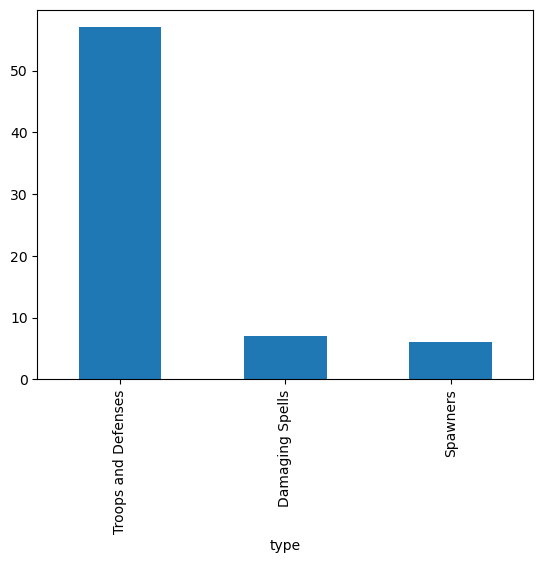

In [78]:
df['type'].value_counts().plot(kind='bar')

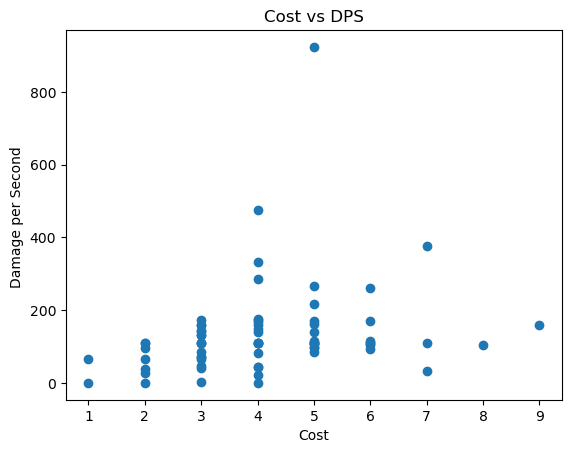

In [80]:
plt.scatter(df['cost'], df['dps'])
plt.xlabel("Cost")
plt.ylabel("Damage per Second ")
plt.title("Cost vs DPS")
plt.show()

<Axes: xlabel='card'>

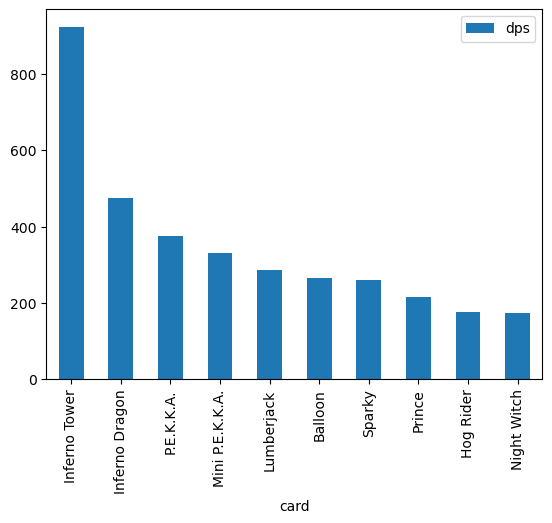

In [81]:
# Highest damage dealing cards 
df.sort_values(by='dps', ascending=False).head(10).plot(
    x='card', y='dps', kind='bar'
)

<Axes: xlabel='has_shield'>

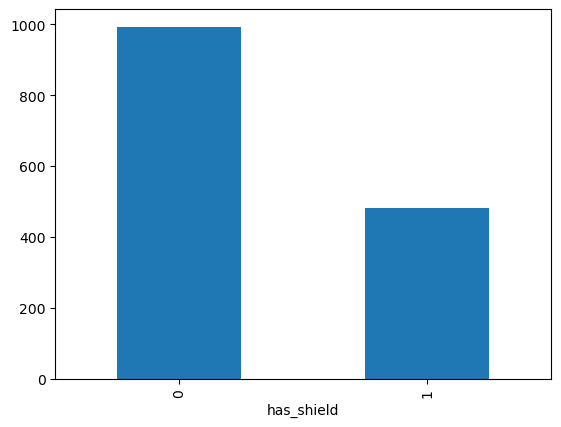

In [82]:
df['has_shield'] = (df['shield_hp'] > 0).astype(int)

df.groupby('has_shield')['base_hp'].mean().plot(kind='bar')

<Axes: ylabel='count'>

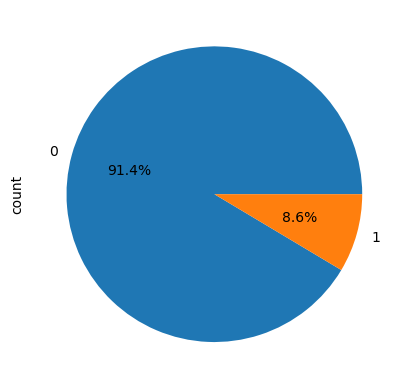

In [83]:
df['has_spawn'].value_counts().plot(kind='pie', autopct='%1.1f%%')

In [69]:
df.sample(5)

,card,cost,count,tower_damage,damage,dps,Death_damage,hit_speed,level,max_spawn,...,spawn_speed,spawner_health,troop_spawned,type,card_level,spawn_level,base_hp,shield_hp,has_spawn,has_tower_damage
55,Witch,5.0,1.0,0.0,69.0,98.0,0.0,0.7,4.0,0.0,...,0.0,0,None,Troops and Defenses,0,0.0,696.0,0.0,1,1
10,Bowler,5.0,1.0,0.0,239.0,95.0,0.0,2.5,4.0,0.0,...,0.0,0,None,Troops and Defenses,0,0.0,1596.0,0.0,1,1
19,Giant,5.0,1.0,0.0,211.0,140.0,0.0,1.5,7.0,0.0,...,0.0,0,None,Troops and Defenses,0,0.0,3344.0,0.0,1,1
23,Golem,8.0,1.0,0.0,259.0,103.0,259.0,2.5,4.0,0.0,...,0.0,0,None,Troops and Defenses,0,0.0,4256.0,0.0,1,1
53,Three Musketeers,9.0,3.0,0.0,176.0,160.0,0.0,1.1,7.0,0.0,...,0.0,0,None,Troops and Defenses,0,0.0,598.0,0.0,1,1


In [70]:
df.to_csv("cleaned_dataset.csv", index=False)